In [ ]:
# Re-import and redefine all necessary components after environment reset

from enum import Enum
import random
from typing import Tuple, List, Optional
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt
import pandas as pd


# Define new card values and suits
NEW_VALUES = ['T', 'J', 'Q', 'K', 'A']
SUITS = ['♠', '♥']

# Redefine Card class
class Card:
    def __init__(self, value: str, suit: str):
        self.value = value
        self.suit = suit

    def __repr__(self):
        return f"{self.value}{self.suit}"

    def value_rank(self):
        return NEW_VALUES.index(self.value)

def evaluate_hand(card: Card, table_card: Card) -> Tuple[float, int]:
    pair = card.value == table_card.value
    straight = abs(card.value_rank() - table_card.value_rank()) == 1
    color = card.suit == table_card.suit
    straight_flush = straight and color

    if pair:
        rank = 3
    elif straight_flush:
        rank = 2.5
    elif straight:
        rank = 2
    elif color:
        rank = 1
    else:
        rank = 0

    max_val = max(card.value_rank(), table_card.value_rank())
    return (rank, max_val)

# Payoffs
PAYOFFS = {
    'fold': 1,
    'call_r1': [2, -2],
    'call_r2': [3, -3],
    'C': [1, -1],
    'C1': [2, -2],
    'C2': [3, -3]
}

# Base agent
class BaseAgent:
    def act(self, card: Card, table_card: Optional[Card], stage: int, history: List[str]) -> str:
        raise NotImplementedError #TODO 

    def update(self, reward: int, history: List[str]):
        pass


# MiniPokerGame with two stages
class MiniPokerGame:
    def __init__(self, agent1, agent2):
        self.agent1 = agent1
        self.agent2 = agent2
        self.deck = [Card(v, s) for v in NEW_VALUES for s in SUITS]

    def play_round(self):
        deck = self.deck[:]
        random.shuffle(deck)
        card1, card2 = deck.pop(), deck.pop()
        table_card = None
        history = []

        # Stage 1: Player 1 acts
        print(f"The game begins with history {history}")
        a1 = self.agent1.act(card1, None, 1, history)
        history.append(f"P1-{a1}")
        print(f"P1 played {history}")

        # Player 2 responds
        if a1 == 'C': # P2 responds to a check by checking or raising
            a2 = self.agent2.act(card2, None, 1, history)
            history.append(f"P2-{a2}")
            if a2 == 'C':
                table_card = deck.pop()
            elif a2 in ['R1', 'R2']: # if P2 raises, P1 needs to respond
                # P1 gets to respond
                a1_r = self.agent1.act(card1, None, 1, history)
                if a1_r in ['R1', 'R2']:
                    raise ValueError("Player 1 attempted to raise to a raise in stage 1.")
                if (a2 == 'R1' and a1_r != 'C1') or (a2 == 'R2' and a1_r != 'C2'):
                    if a1_r != 'F':
                        raise ValueError(f"Invalid response to {a2}: expected F or {'C1' if a2 == 'R1' else 'C2'}")
                history.append(f"P1-{a1_r}")
                if a1_r == 'F': # if P1 folds, the game ends
                    return -1, 1, history, card1, card2, None
                else: # if p1 calls, the game continues by drawing a card to the table
                    table_card = deck.pop()
            elif a2 == 'F':# if p2 folds, game over
                return 1, -1, history, card1, card2, None

        elif a1 in ['R1', 'R2']: #if p1 raises, p2 can call or fold. No reraises allowed.
            a2 = self.agent2.act(card2, None, 1, history)
            if (a1 == 'R1' and a2 != 'C1') and a2 != 'F':
                raise ValueError("Invalid response to R1: must be C1 or F")
            if (a1 == 'R2' and a2 != 'C2') and a2 != 'F':
                raise ValueError("Invalid response to R2: must be C2 or F")
            history.append(f"P2-{a2}")
            if a2 == 'F': # if p2 folds, game over
                return 1, -1, history, card1, card2, None
            else:
                table_card = deck.pop()
        else:
            return 0, 0, history, card1, card2, None

        # Stage 2: Player 1 acts
        a1_2 = self.agent1.act(card1, table_card, 2, history)
        history.append(f"P1-{a1_2}")

        if a1_2 == 'C': # if p1 checks to p2, ...
            a2_2 = self.agent2.act(card2, table_card, 2, history)
            history.append(f"P2-{a2_2}")
            if a2_2 == 'C': #p2 can check
                return self.resolve(card1, card2, table_card, 'C') + (history, card1, card2, table_card)
            if (a1_2 == 'C' and a2_2 not in ['C', 'R1', 'R2']):
                raise ValueError(f"Invalid response {a2_2} to {a1_2} in stage 2.")
            elif a2_2 in ['R1', 'R2']: #p2 can raise
                # P1 responds to raise
                a1_r2 = self.agent1.act(card1, table_card, 2, history)
                if a2_2 == 'R1' and a1_r2 != 'C1' and a1_r2 != 'F':
                    raise ValueError("Invalid response to R1 in stage 2: must be C1 or F")
                if a2_2 == 'R2' and a1_r2 != 'C2' and a1_r2 != 'F':
                    raise ValueError("Invalid response to R2 in stage 2: must be C2 or F")

                history.append(f"P1-{a1_r2}")
                if a1_r2 == 'F': #if p1 folds, game over
                    return -1, 1, history, card1, card2, table_card
                else:  #if p1 calls, the game is resolved 
                    return self.resolve(card1, card2, table_card, a1_r2) + (history, card1, card2, table_card)
        elif a1_2 in ['R1', 'R2']: #if p1 raises, ...
            a2_2 = self.agent2.act(card2, table_card, 2, history)
            if (a1_2 == 'R1' and a2_2 != 'C1') and a2_2 != 'F':
                raise ValueError("Invalid response to R1 in stage 2: must be C1 or F")
            if (a1_2 == 'R2' and a2_2 != 'C2') and a2_2 != 'F':
                raise ValueError("Invalid response to R2 in stage 2: must be C2 or F")
            history.append(f"P2-{a2_2}")
            if a2_2 == 'F': #p2 folds, game over. Any raise in the previous round is not important in the payoffs
                return 1, -1, history, card1, card2, table_card
            elif a2_2 in ['C1', 'C2']: #p2 can call and the game is resolved
                return self.resolve(card1, card2, table_card, a2_2) + (history, card1, card2, table_card)

        return 0, 0, history, card1, card2, table_card

    def resolve(self, card1: Card, card2: Card, table_card: Optional[Card], call_type: str) -> Tuple[int, int]:
        if table_card is None:
            return 0, 0  # Defensive fallback, though table_card should always be set here
        h1 = evaluate_hand(card1, table_card)
        h2 = evaluate_hand(card2, table_card)
        if h1 > h2:
            return PAYOFFS[call_type][0], PAYOFFS[call_type][1]
        elif h2 > h1:
            return PAYOFFS[call_type][1], PAYOFFS[call_type][0]
        else:
            return 0, 0  # Tie


In [2]:
# Tournament class with card info and exportable match history
class Tournament:
    def __init__(self, agents: List[Tuple[str, BaseAgent]]):
        self.agents = agents
        self.scores = defaultdict(int)
        self.histories = defaultdict(list)

    def run(self, rounds: int = 100):
        for i, (name1, agent1) in enumerate(self.agents):
            for j, (name2, agent2) in enumerate(self.agents):
                if i != j:
                    game = MiniPokerGame(agent1, agent2)
                    for _ in range(rounds):
                        r1, r2, hist, c1, c2, tc = game.play_round()
                        self.scores[name1] += r1
                        self.scores[name2] += r2
                        self.histories[(name1, name2)].append({
                            'history': hist,
                            'P1 Card': str(c1),
                            'P2 Card': str(c2),
                            'Table Card': str(tc) if tc else None,
                            'P1 Reward': r1,
                            'P2 Reward': r2
                        })

    def leaderboard(self):
        print("=== Tournament Leaderboard ===")
        sorted_scores = sorted(self.scores.items(), key=lambda x: x[1], reverse=True)
        for rank, (name, score) in enumerate(sorted_scores, start=1):
            print(f"{rank}. {name}: {score}")

    def plot_scores(self):
        names = list(self.scores.keys())
        scores = [self.scores[name] for name in names]
        plt.figure(figsize=(10, 5))
        plt.bar(names, scores, color='skyblue')
        plt.xlabel("Agent")
        plt.ylabel("Total Score")
        plt.title("Mini Poker Tournament Scores")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

    def export_match_history(self, player1_name: str, player2_name: str) -> pd.DataFrame:
        key = (player1_name, player2_name)
        if key not in self.histories:
            return pd.DataFrame()
        
        full_rows = []
        for match in self.histories[key]:
            for event in match['history']:
                player, action = event.split('-')
                full_rows.append({
                    'Player': player,
                    'Action': action,
                    'P1 Card': match['P1 Card'],
                    'P2 Card': match['P2 Card'],
                    'Table Card': match['Table Card'],
                    'P1 Reward': match['P1 Reward'],
                    'P2 Reward': match['P2 Reward']
                })
        return pd.DataFrame(full_rows)

In [3]:
# Example agents [Use these agents as a template to generate your agents!!]

class RandomAgent(BaseAgent):
    def act(self, card: Card, table_card: Optional[Card], stage: int, history: List[str]) -> str:
        def last_opponent_action():
            for entry in reversed(history):
                if (stage == 1 and entry.startswith('P1-')) or (stage == 2 and len(history) % 2 == 1 and entry.startswith('P1-')) or (stage == 2 and len(history) % 2 == 0 and entry.startswith('P2-')):
                    return entry.split('-')[1]
            return None

        if stage == 1:
            if len(history) == 0:
                choice = random.choice(['C', 'R1', 'R2'])  # P1 acting
                print(f"[Random] I'm Random, opening with {choice}")
                return choice

            elif len(history) == 1:
                p1_action = history[0].split('-')[1]
                options = ['F', 'C1'] if p1_action == 'R1' else ['F', 'C2'] if p1_action == 'R2' else ['C', 'R1', 'R2']
                choice = random.choice(options)
                print(f"[DEBUG Stage 1, P2] P1 played {p1_action}, RandomAgent chooses {choice}")
                return choice

            elif len(history) == 2:
                p2_action = history[1].split('-')[1]
                options = ['F', 'C1'] if p2_action == 'R1' else ['F', 'C2'] if p2_action == 'R2' else ['C', 'R1', 'R2']
                choice = random.choice(options)
                print(f"[DEBUG Stage 1, P1 resp] P2 played {p2_action}, RandomAgent chooses {choice}")
                return choice

        elif stage == 2:
            if len(history) % 2 == 0:
                # P1 acting in Stage 2
                if len(history) >= 1:
                    last_action = history[-1].split('-')[1]
                    if last_action in ['R1', 'R2']:
                        options = ['F', 'C1'] if last_action == 'R1' else ['F', 'C2']
                        choice = random.choice(options)
                        print(f"[DEBUG Stage 2, P1 resp] P2 raised {last_action}, RandomAgent chooses {choice}")
                        return choice
                return random.choice(['C', 'R1', 'R2'])

            else:
                # P2 acting in Stage 2
                p1_action = history[-1].split('-')[1]
                options = ['F', 'C1'] if p1_action == 'R1' else ['F', 'C2'] if p1_action == 'R2' else ['C', 'R1', 'R2']
                choice = random.choice(options)
                print(f"[DEBUG Stage 2, P2] P1 played {p1_action}, RandomAgent chooses {choice}")
                return choice


# Passive agent that only checks or folds against raises
class PassiveAgent(BaseAgent):
    def act(self, card: Card, table_card: Optional[Card], stage: int, history: List[str]) -> str:
        def last_opponent_action():
            for entry in reversed(history):
                if (stage == 1 and entry.startswith('P1-')) or (stage == 2 and len(history) % 2 == 1 and entry.startswith('P1-')) or (stage == 2 and len(history) % 2 == 0 and entry.startswith('P2-')):
                    return entry.split('-')[1]
            return None

        if stage == 1:
            if len(history) == 0:
                print("[Passive] I'm Passive, opening with Check")
                return 'C'  # P1 acting

            elif len(history) == 1:
                p1_action = history[0].split('-')[1]
                options = ['F', 'C1'] if p1_action == 'R1' else ['F', 'C2'] if p1_action == 'R2' else ['C', 'R1', 'R2']
                choice = options[0] # fold against raise, call any check
                print(f"[DEBUG Stage 1, P2] P1 played {p1_action}, Passive agent chooses {choice}")
                return choice

            elif len(history) == 2:
                p2_action = history[1].split('-')[1]
                options = ['F', 'C1'] if p2_action == 'R1' else ['F', 'C2'] if p2_action == 'R2' else ['C', 'R1', 'R2']
                choice = options[0]
                print(f"[DEBUG Stage 1, P1 resp] P2 played {p2_action}, Passive agent chooses {choice}")
                return choice

        elif stage == 2:
            if len(history) % 2 == 0:
                # P1 acting in Stage 2
                if len(history) >= 1:
                    last_action = history[-1].split('-')[1]
                    if last_action in ['R1', 'R2']:
                        options = ['F', 'C1'] if last_action == 'R1' else ['F', 'C2']
                        choice = options[0]
                        print(f"[DEBUG Stage 2, P1 resp] P2 raised {last_action}, Passive agent chooses {choice}")
                        return choice
                return 'C'

            else:
                # P2 acting in Stage 2
                p1_action = history[-1].split('-')[1]
                options = ['F', 'C1'] if p1_action == 'R1' else ['F', 'C2'] if p1_action == 'R2' else ['C', 'R1', 'R2']
                choice = options[0]
                print(f"[DEBUG Stage 2, P2] P1 played {p1_action}, Passive agent chooses {choice}")
                return choice





# Aggressive agent that always raises or calls when allowed
class AggressiveAgent(BaseAgent):
    def act(self, card: Card, table_card: Optional[Card], stage: int, history: List[str]) -> str:
        def last_opponent_action():
            for entry in reversed(history):
                if (stage == 1 and entry.startswith('P1-')) or (stage == 2 and len(history) % 2 == 1 and entry.startswith('P1-')) or (stage == 2 and len(history) % 2 == 0 and entry.startswith('P2-')):
                    return entry.split('-')[1]
            return None
        
        if stage == 1:
            if len(history) == 0:
                print("[AGGRESSIVE] I'm Aggressive, opening with R2")
                return 'R2'

            elif len(history) == 1:
                p1_action = history[0].split('-')[1]
                options = ['F', 'C1'] if p1_action == 'R1' else ['F', 'C2'] if p1_action == 'R2' else ['C', 'R1', 'R2']
                choice = options[-1] # fold against raise, call any check
                print(f"[DEBUG Stage 1, P2] P1 played {p1_action}, Aggressive agent chooses {choice}")
                return choice

            elif len(history) == 2:
                p2_action = history[1].split('-')[1]
                options = ['F', 'C1'] if p2_action == 'R1' else ['F', 'C2'] if p2_action == 'R2' else ['C', 'R1', 'R2']
                choice = options[-1]
                print(f"[DEBUG Stage 1, P1 resp] P2 played {p2_action}, Aggressive agent chooses {choice}")
                return choice

        elif stage == 2:
            if len(history) % 2 == 0:
                # P1 acting in Stage 2
                if len(history) >= 1:
                    last_action = history[-1].split('-')[1]
                    if last_action in ['R1', 'R2']:
                        options = ['F', 'C1'] if last_action == 'R1' else ['F', 'C2']
                        choice = options[-1]
                        print(f"[DEBUG Stage 2, P1 resp] P2 raised {last_action}, Aggressive agent chooses {choice}")
                        return choice
                return 'C'

            else:
                # P2 acting in Stage 2
                p1_action = history[-1].split('-')[1]
                options = ['F', 'C1'] if p1_action == 'R1' else ['F', 'C2'] if p1_action == 'R2' else ['C', 'R1', 'R2']
                choice = options[-1]
                print(f"[DEBUG Stage 2, P2] P1 played {p1_action}, Aggressive agent chooses {choice}")
                return choice


In [ ]:
# [ADD YOUR AGENT HERE]

In [4]:
# Simulate game and parse history
history = []
game = MiniPokerGame(RandomAgent(), AggressiveAgent()) # random player (P1) against an Aggresive (P2) player
r1, r2, history, card1, card2, table_card = game.play_round()

parsed_history = [{
    'Player': h.split('-')[0],
    'Action': h.split('-')[1],
    'P1 Card': str(card1),
    'P2 Card': str(card2),
    'Table Card': str(table_card) if table_card else None,
    'P1 Reward': r1,
    'P2 Reward': r2
} for h in history]

pd.DataFrame(parsed_history)

The game begins with history []
[Random] I'm Random, opening with R1
P1 played ['P1-R1']
[DEBUG Stage 1, P2] P1 played R1, Aggressive agent chooses C1
[DEBUG Stage 2, P2] P1 played R1, Aggressive agent chooses C1


,Player,Action,P1 Card,P2 Card,Table Card,P1 Reward,P2 Reward
0,P1,R1,J♥,K♠,T♠,2,-2
1,P2,C1,J♥,K♠,T♠,2,-2
2,P1,R1,J♥,K♠,T♠,2,-2
3,P2,C1,J♥,K♠,T♠,2,-2


The game begins with history []
[AGGRESSIVE] I'm Aggressive, opening with R2
P1 played ['P1-R2']
[DEBUG Stage 1, P2] P1 played R2, RandomAgent chooses C2
[DEBUG Stage 2, P2] P1 played C, RandomAgent chooses R1
[DEBUG Stage 2, P1 resp] P2 raised R1, Aggressive agent chooses C1
The game begins with history []
[AGGRESSIVE] I'm Aggressive, opening with R2
P1 played ['P1-R2']
[DEBUG Stage 1, P2] P1 played R2, RandomAgent chooses C2
[DEBUG Stage 2, P2] P1 played C, RandomAgent chooses C
The game begins with history []
[AGGRESSIVE] I'm Aggressive, opening with R2
P1 played ['P1-R2']
[DEBUG Stage 1, P2] P1 played R2, RandomAgent chooses C2
[DEBUG Stage 2, P2] P1 played C, RandomAgent chooses C
The game begins with history []
[AGGRESSIVE] I'm Aggressive, opening with R2
P1 played ['P1-R2']
[DEBUG Stage 1, P2] P1 played R2, RandomAgent chooses F
The game begins with history []
[AGGRESSIVE] I'm Aggressive, opening with R2
P1 played ['P1-R2']
[DEBUG Stage 1, P2] P1 played R2, RandomAgent chooses C

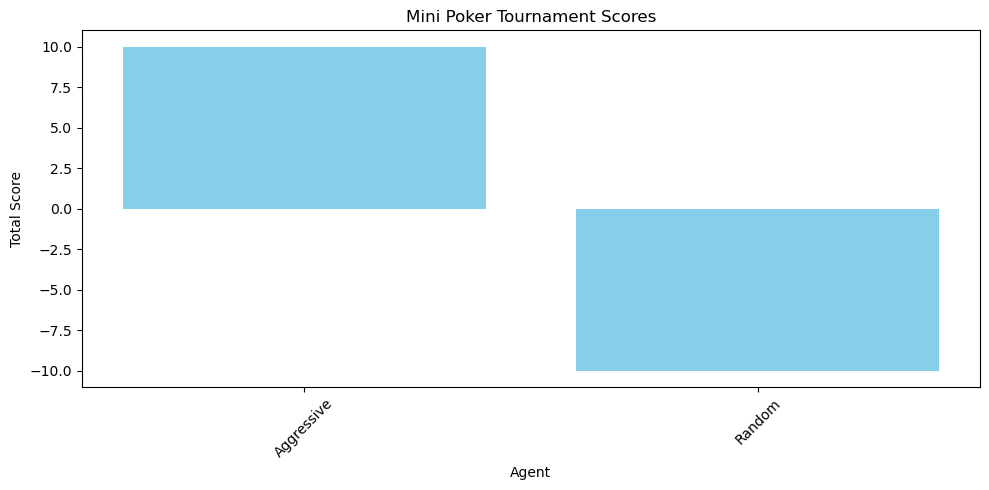

In [5]:
# Run a tournament of RandomAgent vs AggressiveAgemt

agents = [
    ("Aggressive", AggressiveAgent()),
    ("Random", RandomAgent())
] # You can include more than two agents in this list. The tournament will just have them play each other a pair at a time.

tourney = Tournament(agents)
tourney.run(rounds=10)
tourney.leaderboard()
tourney.plot_scores()

In [5]:
# A small exemplary test to manually test the resolve function [You do not need this to run your code. This code is here just for information purposes]

# Create a fake game instance with resolve logic
game = MiniPokerGame(RandomAgent(), RandomAgent())

# Example test cases
test_cases = [
    (Card('A', '♥'), Card('K', '♥'), Card('Q', '♥'), 'C'),   # straight flush vs flush
    (Card('K', '♠'), Card('Q', '♠'), Card('J', '♠'), 'C2'),  # straight flush vs straight flush
    (Card('T', '♠'), Card('T', '♥'), Card('J', '♠'), 'C'),   # pair vs color
    (Card('J', '♥'), Card('J', '♠'), Card('T', '♥'), 'C1'),   # straight flush vs straight
    (Card('T', '♠'), Card('Q', '♠'), Card('K', '♥'), 'C2'),   # high card vs straight
    ]

results = []
for card1, card2, table, calltype in test_cases:
    result = game.resolve(card1, card2, table, calltype)
    results.append({
        'P1': str(card1),
        'P2': str(card2),
        'Table': str(table),
        'Call': calltype,
        'P1_Payoff': result[0],
        'P2_Payoff': result[1]
    })

import pandas as pd
df = pd.DataFrame(results)
print(df)


   P1  P2 Table Call  P1_Payoff  P2_Payoff
0  A♥  K♥    Q♥    C         -1          1
1  K♠  Q♠    J♠   C2         -3          3
2  T♠  T♥    J♠    C          1         -1
3  J♥  J♠    T♥   C1          2         -2
4  T♠  Q♠    K♥   C2         -3          3
